# Part 2: Advanced Deep Learning Constructs — Keras & PyTorch
**Author:** Kalhar Mayurbhai Patel (019140511)

This single notebook covers 12 advanced topics:
1. Custom Learning Rate Scheduler
2. Custom Dropout (MCAlphaDropout)
3. Custom Normalization (MaxNormDense)
4. TensorBoard Integration
5. Custom Loss Function (Huber)
6. Custom Activation, Initializer, Regularizer, Constraint
7. Custom Metric
8. Custom Layers
9. Custom Model (Residual Network)
10. Custom Optimizer
11. Custom Training Loop
12. Weights & Biases Integration

Each section demonstrates concepts in **both TensorFlow and PyTorch**.

In [1]:
# Common imports and data setup
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch
import torch.nn as nn
import os, shutil

# Load Fashion MNIST for demonstrations
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

# PyTorch tensors
X_tr_pt = torch.FloatTensor(X_train).unsqueeze(1)  # Add channel dim
y_tr_pt = torch.LongTensor(y_train)
X_val_pt = torch.FloatTensor(X_valid).unsqueeze(1)
y_val_pt = torch.LongTensor(y_valid)
X_te_pt = torch.FloatTensor(X_test).unsqueeze(1)
y_te_pt = torch.LongTensor(y_test)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (55000, 28, 28), Valid: (5000, 28, 28), Test: (10000, 28, 28)


/tmp/ipykernel_19354/683883430.py:21: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  y_tr_pt = torch.LongTensor(y_train)


---
## 1. Custom Learning Rate Scheduler

### OneCycle Policy
The 1cycle policy warms up the LR from a low value to a max, then anneals it down.
This often gives faster convergence and better generalization.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


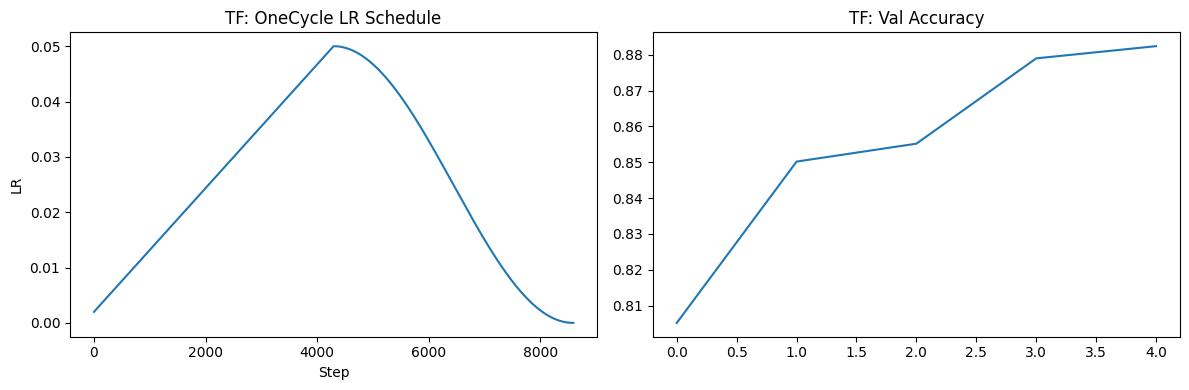

TF OneCycle Val Acc: 0.8824


In [2]:
# ==================== TensorFlow ====================

class OneCycleScheduler(keras.callbacks.Callback):
    """Implements the 1cycle learning rate policy.
    Linearly increases LR for first half, then cosine anneals down."""
    def __init__(self, max_lr, steps_per_epoch, epochs, start_lr=None, end_lr=None):
        self.max_lr = max_lr
        self.start_lr = start_lr or max_lr / 25
        self.end_lr = end_lr or self.start_lr / 1000
        self.total_steps = steps_per_epoch * epochs
        self.half_steps = self.total_steps // 2
        self.step_count = 0
        self.history = []

    def on_train_batch_begin(self, batch, logs=None):
        if self.step_count < self.half_steps:
            lr = self.start_lr + (self.max_lr - self.start_lr) * self.step_count / self.half_steps
        else:
            progress = (self.step_count - self.half_steps) / max(self.total_steps - self.half_steps, 1)
            lr = self.end_lr + (self.max_lr - self.end_lr) * 0.5 * (1 + np.cos(np.pi * progress))
        self.step_count += 1
        self.history.append(lr)
        self.model.optimizer.learning_rate.assign(lr)

# Flatten for Dense network
X_tr_flat = X_train.reshape(-1, 784)
X_val_flat = X_valid.reshape(-1, 784)

model_1c = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_1c.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])

steps = len(X_tr_flat) // 32
onecycle = OneCycleScheduler(max_lr=0.05, steps_per_epoch=steps, epochs=5)
h1 = model_1c.fit(X_tr_flat, y_train, epochs=5, batch_size=32,
                   validation_data=(X_val_flat, y_valid), callbacks=[onecycle], verbose=0)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(onecycle.history)
plt.title('TF: OneCycle LR Schedule'); plt.xlabel('Step'); plt.ylabel('LR')
plt.subplot(1, 2, 2)
plt.plot(h1.history['val_accuracy']); plt.title('TF: Val Accuracy')
plt.tight_layout(); plt.show()
print(f"TF OneCycle Val Acc: {h1.history['val_accuracy'][-1]:.4f}")

PT OneCycle Val Acc: 0.8926


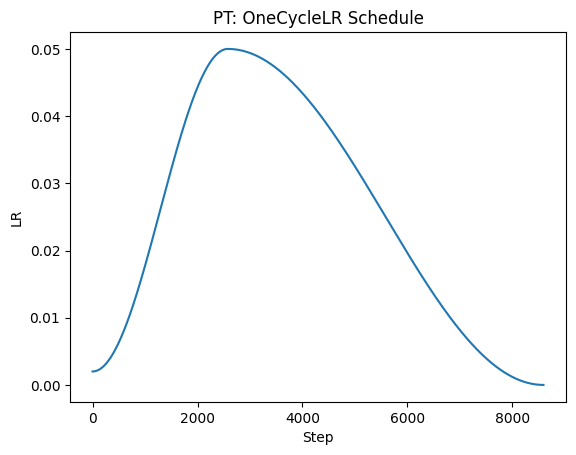

In [3]:
# ==================== PyTorch ====================
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class PTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(), nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

torch.manual_seed(42)
pt_model_1 = PTNet().to(device)
pt_opt = torch.optim.SGD(pt_model_1.parameters(), lr=0.01)
pt_dl = DataLoader(TensorDataset(X_tr_pt.to(device), y_tr_pt.to(device)),
                   batch_size=32, shuffle=True)

pt_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    pt_opt, max_lr=0.05, steps_per_epoch=len(pt_dl), epochs=5
)
crit = nn.CrossEntropyLoss()
lrs = []

for ep in range(5):
    pt_model_1.train()
    for xb, yb in pt_dl:
        loss = crit(pt_model_1(xb), yb)
        pt_opt.zero_grad(); loss.backward(); pt_opt.step()
        lrs.append(pt_opt.param_groups[0]['lr'])
        pt_scheduler.step()

pt_model_1.eval()
with torch.no_grad():
    pred = pt_model_1(X_val_pt.to(device)).argmax(1)
    acc = (pred == y_val_pt.to(device)).float().mean().item()
print(f"PT OneCycle Val Acc: {acc:.4f}")
plt.plot(lrs); plt.title('PT: OneCycleLR Schedule'); plt.xlabel('Step'); plt.ylabel('LR'); plt.show()

---
## 2. Custom Dropout: MC Alpha Dropout

Alpha Dropout maintains the self-normalizing property of SELU networks.
We implement it from scratch in both frameworks.

In [4]:
# ==================== TensorFlow ====================

class MCAlphaDropout(layers.Layer):
    """Monte Carlo Alpha Dropout — stays active at inference for uncertainty estimation."""
    def __init__(self, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        # Always apply dropout (MC style)
        alpha = -1.7580993408473766
        scale = 1.0507009873554805
        sat = alpha * scale
        mask = tf.random.uniform(tf.shape(inputs)) >= self.rate
        mask = tf.cast(mask, inputs.dtype)
        output = tf.where(mask > 0, inputs, sat * tf.ones_like(inputs))
        a = ((1 - self.rate) * (1 + self.rate * sat**2)) ** (-0.5)
        b = -a * sat * self.rate
        return a * output + b

model_2tf = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation='selu', kernel_initializer='lecun_normal'),
    MCAlphaDropout(0.1),
    layers.Dense(128, activation='selu', kernel_initializer='lecun_normal'),
    MCAlphaDropout(0.1),
    layers.Dense(10, activation='softmax')
])
model_2tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_2tf.fit(X_train, y_train, epochs=5, batch_size=64,
              validation_data=(X_valid, y_valid), verbose=0)

# MC inference: 30 forward passes
mc_preds = np.stack([model_2tf(X_test[:100], training=True).numpy() for _ in range(30)])
mean_preds = mc_preds.mean(axis=0)
uncertainty = mc_preds.std(axis=0).mean(axis=1)
predicted = mean_preds.argmax(axis=1)
print(f"TF MC AlphaDropout Acc (100 samples): {(predicted == y_test[:100]).mean():.4f}")
print(f"Avg uncertainty: {uncertainty.mean():.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


TF MC AlphaDropout Acc (100 samples): 0.8800
Avg uncertainty: 0.0102


In [5]:
# ==================== PyTorch ====================

class MCAlphaDropoutPT(nn.Module):
    """MC Alpha Dropout for PyTorch SELU networks."""
    def __init__(self, rate=0.1):
        super().__init__()
        self.rate = rate

    def forward(self, x):
        alpha = -1.7580993408473766
        scale = 1.0507009873554805
        sat = alpha * scale
        mask = (torch.rand_like(x) >= self.rate).float()
        output = torch.where(mask > 0, x, torch.full_like(x, sat))
        a = ((1 - self.rate) * (1 + self.rate * sat**2)) ** (-0.5)
        b = -a * sat * self.rate
        return a * output + b

class SELUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(), nn.Linear(784, 256), nn.SELU(),
            MCAlphaDropoutPT(0.1),
            nn.Linear(256, 128), nn.SELU(),
            MCAlphaDropoutPT(0.1),
            nn.Linear(128, 10)
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='linear')
    def forward(self, x): return self.net(x)

torch.manual_seed(42)
pt_m2 = SELUNet().to(device)
opt2 = torch.optim.Adam(pt_m2.parameters())
for ep in range(5):
    pt_m2.train()
    for xb, yb in pt_dl:
        opt2.zero_grad(); crit(pt_m2(xb), yb).backward(); opt2.step()

# MC inference
pt_m2.train()  # Keep dropout active
with torch.no_grad():
    mc = torch.stack([pt_m2(X_te_pt[:100].to(device)) for _ in range(30)])
    mean_p = mc.mean(0).argmax(1)
    print(f"PT MC AlphaDropout Acc: {(mean_p.cpu() == y_te_pt[:100]).float().mean():.4f}")

PT MC AlphaDropout Acc: 0.8500


---
## 3. Custom Normalization: MaxNorm Dense

MaxNorm constrains the weight norm of each neuron after each update.
If ||w|| > max_norm, rescale w so that ||w|| = max_norm.

In [7]:
# ==================== TensorFlow ====================

class MaxNormDense(layers.Layer):
    """Dense layer with max-norm weight constraint applied after each update."""
    def __init__(self, units, max_norm=1.0, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.max_norm = max_norm
        self.activation = keras.activations.get(activation)

    def build(self, input_shape):
        self.kernel = self.add_weight(name='kernel', shape=(input_shape[-1], self.units),
                                       initializer='glorot_uniform')
        self.bias = self.add_weight(name='bias', shape=(self.units,), initializer='zeros')

    def call(self, inputs):
        # Use the kernel as-is during forward pass; constraint applied via callback
        output = tf.matmul(inputs, self.kernel) + self.bias
        return self.activation(output) if self.activation else output

class MaxNormCallback(keras.callbacks.Callback):
    """Apply max-norm constraint after each batch update."""
    def __init__(self, max_norm=1.0):
        self.max_norm = max_norm
    def on_train_batch_end(self, batch, logs=None):
        for layer in self.model.layers:
            if isinstance(layer, MaxNormDense):
                clipped = tf.clip_by_norm(layer.kernel, self.max_norm, axes=[0])
                layer.kernel.assign(clipped)

m3tf = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    MaxNormDense(256, max_norm=1.0, activation='relu'),
    MaxNormDense(128, max_norm=1.0, activation='relu'),
    layers.Dense(10, activation='softmax')
])
m3tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h3 = m3tf.fit(X_train, y_train, epochs=5, batch_size=64,
              validation_data=(X_valid, y_valid), callbacks=[MaxNormCallback(1.0)], verbose=0)
print(f"TF MaxNormDense Val Acc: {h3.history['val_accuracy'][-1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


TF MaxNormDense Val Acc: 0.8798


In [8]:
# ==================== PyTorch ====================

class MaxNormLinear(nn.Module):
    """Linear layer with max-norm constraint on weights."""
    def __init__(self, in_features, out_features, max_norm=1.0):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.max_norm = max_norm

    def forward(self, x):
        # Apply max norm constraint
        with torch.no_grad():
            norms = self.linear.weight.norm(dim=1, keepdim=True)
            desired = torch.clamp(norms, max=self.max_norm)
            self.linear.weight.mul_(desired / (norms + 1e-8))
        return self.linear(x)

class MaxNormNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            MaxNormLinear(784, 256, max_norm=1.0), nn.ReLU(),
            MaxNormLinear(256, 128, max_norm=1.0), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

torch.manual_seed(42)
pt_m3 = MaxNormNet().to(device)
opt3 = torch.optim.Adam(pt_m3.parameters())
for ep in range(5):
    pt_m3.train()
    for xb, yb in pt_dl:
        opt3.zero_grad(); crit(pt_m3(xb), yb).backward(); opt3.step()
pt_m3.eval()
with torch.no_grad():
    acc = (pt_m3(X_val_pt.to(device)).argmax(1) == y_val_pt.to(device)).float().mean()
print(f"PT MaxNormNet Val Acc: {acc:.4f}")

PT MaxNormNet Val Acc: 0.8682


---
## 4. TensorBoard Integration

Log scalars, histograms, images, and computation graphs.

In [9]:
# ==================== TensorFlow ====================
log_dir = 'logs/part2_tf'
if os.path.exists(log_dir): shutil.rmtree(log_dir)

m4tf = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
m4tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

tb_cb = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1,
                                     write_graph=True, write_images=True)
m4tf.fit(X_train, y_train, epochs=5, batch_size=64,
         validation_data=(X_valid, y_valid), callbacks=[tb_cb], verbose=0)
print(f"TF TensorBoard logs written to {log_dir}")
print("Launch with: tensorboard --logdir logs/part2_tf")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


TF TensorBoard logs written to logs/part2_tf
Launch with: tensorboard --logdir logs/part2_tf


In [10]:
# ==================== PyTorch ====================
from torch.utils.tensorboard import SummaryWriter

log_dir_pt = 'logs/part2_pt'
if os.path.exists(log_dir_pt): shutil.rmtree(log_dir_pt)
writer = SummaryWriter(log_dir_pt)

torch.manual_seed(42)
pt_m4 = PTNet().to(device)
opt4 = torch.optim.Adam(pt_m4.parameters())

# Log model graph
dummy = torch.zeros(1, 1, 28, 28).to(device)
writer.add_graph(pt_m4, dummy)

# Log sample images
writer.add_images('sample_images', X_tr_pt[:16], 0)

for ep in range(5):
    pt_m4.train(); total_loss = 0
    for xb, yb in pt_dl:
        loss = crit(pt_m4(xb), yb)
        opt4.zero_grad(); loss.backward(); opt4.step()
        total_loss += loss.item()
    pt_m4.eval()
    with torch.no_grad():
        val_acc = (pt_m4(X_val_pt.to(device)).argmax(1) == y_val_pt.to(device)).float().mean()
    writer.add_scalar('Loss/train', total_loss/len(pt_dl), ep)
    writer.add_scalar('Accuracy/val', val_acc, ep)
    for name, param in pt_m4.named_parameters():
        writer.add_histogram(name, param, ep)

writer.close()
print(f"PT TensorBoard logs written to {log_dir_pt}")

PT TensorBoard logs written to logs/part2_pt


---
## 5. Custom Loss Function: Huber Loss

Huber loss is quadratic for small errors and linear for large errors,
making it more robust to outliers than MSE.

In [11]:
# ==================== TensorFlow ====================

class HuberLoss(keras.losses.Loss):
    """Huber Loss: quadratic when |error| < delta, linear otherwise."""
    def __init__(self, delta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.delta = delta

    def call(self, y_true, y_pred):
        error = tf.cast(y_true, tf.float32) - tf.cast(y_pred, tf.float32)
        is_small = tf.abs(error) < self.delta
        small_error = 0.5 * tf.square(error)
        large_error = self.delta * (tf.abs(error) - 0.5 * self.delta)
        return tf.where(is_small, small_error, large_error)

# Regression example
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
housing = fetch_california_housing()
X_h = StandardScaler().fit_transform(housing.data)
y_h = housing.target

m5tf = keras.Sequential([layers.Dense(64, activation='relu', input_shape=(8,)),
                          layers.Dense(32, activation='relu'), layers.Dense(1)])
m5tf.compile(optimizer='adam', loss=HuberLoss(delta=1.0), metrics=['mae'])
h5 = m5tf.fit(X_h[:15000], y_h[:15000], epochs=5, batch_size=64,
              validation_split=0.2, verbose=0)
print(f"TF Huber Loss - Val MAE: {h5.history['val_mae'][-1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TF Huber Loss - Val MAE: 0.7038


In [12]:
# ==================== PyTorch ====================

class HuberLossPT(nn.Module):
    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = delta

    def forward(self, y_pred, y_true):
        error = y_true - y_pred
        is_small = error.abs() < self.delta
        small = 0.5 * error ** 2
        large = self.delta * (error.abs() - 0.5 * self.delta)
        return torch.where(is_small, small, large).mean()

X_h_t = torch.FloatTensor(X_h[:15000]).to(device)
y_h_t = torch.FloatTensor(y_h[:15000]).unsqueeze(1).to(device)
X_h_val = torch.FloatTensor(X_h[15000:]).to(device)
y_h_val = torch.FloatTensor(y_h[15000:]).unsqueeze(1).to(device)

pt_m5 = nn.Sequential(nn.Linear(8, 64), nn.ReLU(), nn.Linear(64, 32),
                       nn.ReLU(), nn.Linear(32, 1)).to(device)
opt5 = torch.optim.Adam(pt_m5.parameters())
huber = HuberLossPT(delta=1.0)

# Use DataLoader for proper mini-batch training
h_dl = DataLoader(TensorDataset(X_h_t, y_h_t), batch_size=64, shuffle=True)
for ep in range(5):
    pt_m5.train()
    for xb, yb in h_dl:
        opt5.zero_grad()
        huber(pt_m5(xb), yb).backward()
        opt5.step()

pt_m5.eval()
with torch.no_grad():
    mae = (pt_m5(X_h_val) - y_h_val).abs().mean()
print(f"PT Huber Loss - Val MAE: {mae:.4f}")

PT Huber Loss - Val MAE: 0.5033


---
## 6. Custom Activation, Initializer, Regularizer & Constraint

In [13]:
# ==================== TensorFlow ====================

# Custom activation: Leaky ReLU variant
def my_leaky_relu(x):
    return tf.maximum(0.2 * x, x)

# Custom initializer: Glorot with gain
def my_glorot_initializer(shape, dtype=tf.float32):
    stddev = tf.sqrt(2.0 / (shape[0] + shape[1]))
    return tf.random.normal(shape, stddev=stddev, dtype=dtype)

# Custom regularizer
class MyL1Regularizer(keras.regularizers.Regularizer):
    def __init__(self, factor=0.001):
        self.factor = factor
    def __call__(self, weights):
        return self.factor * tf.reduce_sum(tf.abs(weights))
    def get_config(self):
        return {'factor': self.factor}

# Custom constraint: keep weights positive
class MyPositiveWeights(keras.constraints.Constraint):
    def __call__(self, weights):
        return tf.where(weights < 0, tf.zeros_like(weights), weights)

# Use all custom components
m6tf = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation=my_leaky_relu,
                 kernel_initializer=my_glorot_initializer,
                 kernel_regularizer=MyL1Regularizer(0.001),
                 kernel_constraint=MyPositiveWeights()),
    layers.Dense(10, activation='softmax')
])
m6tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h6 = m6tf.fit(X_train, y_train, epochs=5, batch_size=64,
              validation_data=(X_valid, y_valid), verbose=0)
print(f"TF Custom components Val Acc: {h6.history['val_accuracy'][-1]:.4f}")

# Verify positive constraint
w = m6tf.layers[1].get_weights()[0]
print(f"Min weight value (should be >= 0): {w.min():.6f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


TF Custom components Val Acc: 0.8276
Min weight value (should be >= 0): 0.000000


In [14]:
# ==================== PyTorch ====================

class LeakyReLUCustom(nn.Module):
    def __init__(self, neg_slope=0.2):
        super().__init__()
        self.neg_slope = neg_slope
    def forward(self, x):
        return torch.where(x > 0, x, self.neg_slope * x)

class PositiveWeightLinear(nn.Module):
    """Linear layer that clamps weights to be non-negative after each forward pass."""
    def __init__(self, in_f, out_f):
        super().__init__()
        self.linear = nn.Linear(in_f, out_f)
        nn.init.xavier_normal_(self.linear.weight)

    def forward(self, x):
        self.linear.weight.data.clamp_(min=0)
        return self.linear(x)

class CustomComponentNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PositiveWeightLinear(784, 128)
        self.act = LeakyReLUCustom(0.2)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.act(self.fc1(self.flatten(x)))
        return self.fc2(x)

    def l1_penalty(self, lam=0.001):
        return lam * sum(p.abs().sum() for p in self.parameters())

torch.manual_seed(42)
pt_m6 = CustomComponentNet().to(device)
opt6 = torch.optim.Adam(pt_m6.parameters())
for ep in range(5):
    pt_m6.train()
    for xb, yb in pt_dl:
        loss = crit(pt_m6(xb), yb) + pt_m6.l1_penalty()
        opt6.zero_grad(); loss.backward(); opt6.step()
pt_m6.eval()
with torch.no_grad():
    acc6 = (pt_m6(X_val_pt.to(device)).argmax(1)==y_val_pt.to(device)).float().mean()
print(f"PT Custom Components Val Acc: {acc6:.4f}")
print(f"Min fc1 weight: {pt_m6.fc1.linear.weight.data.min():.6f}")

PT Custom Components Val Acc: 0.8294
Min fc1 weight: 0.000000


---
## 7. Custom Metric: Huber Metric

In [16]:
# ==================== TensorFlow ====================

class HuberMetric(keras.metrics.Metric):
    """Streaming Huber metric that accumulates over batches."""
    def __init__(self, delta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.delta = delta
        self.total = self.add_weight(name='total', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        error = tf.abs(tf.cast(y_true, tf.float32) - tf.cast(y_pred, tf.float32))
        is_small = error < self.delta
        loss = tf.where(is_small, 0.5 * error**2, self.delta * error - 0.5 * self.delta**2)
        self.total.assign_add(tf.reduce_sum(loss))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        return self.total / self.count

    def reset_state(self):
        self.total.assign(0.0)
        self.count.assign(0.0)

m7tf = keras.Sequential([layers.Dense(32, activation='relu', input_shape=(8,)),
                          layers.Dense(1)])
m7tf.compile(optimizer='adam', loss='mse', metrics=[HuberMetric(name='huber')])
h7 = m7tf.fit(X_h[:15000], y_h[:15000], epochs=5, validation_split=0.2, verbose=0)
print(f"TF Custom Huber Metric (final val): {h7.history['val_huber'][-1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TF Custom Huber Metric (final val): 10.1067


In [17]:
# ==================== PyTorch ====================

class HuberMetricPT:
    """Accumulating Huber metric for PyTorch."""
    def __init__(self, delta=1.0):
        self.delta = delta
        self.reset()

    def reset(self):
        self.total = 0.0
        self.count = 0

    def update(self, y_pred, y_true):
        error = (y_true - y_pred).abs()
        is_small = error < self.delta
        loss = torch.where(is_small, 0.5 * error**2, self.delta * error - 0.5 * self.delta**2)
        self.total += loss.sum().item()
        self.count += y_true.numel()

    def compute(self):
        return self.total / self.count if self.count > 0 else 0

metric = HuberMetricPT(delta=1.0)
pt_m5.eval()
with torch.no_grad():
    metric.update(pt_m5(X_h_val), y_h_val)
print(f"PT Custom Huber Metric: {metric.compute():.4f}")

PT Custom Huber Metric: 0.2205


---
## 8. Custom Layers

We implement:
- **Gaussian Noise Layer**: adds noise during training for regularization
- **Custom Dense Layer**: from scratch with custom logic
- **Exponential Layer**: computes e^x (useful in certain architectures)

In [19]:
# ==================== TensorFlow ====================

class AddGaussianNoise(layers.Layer):
    def __init__(self, stddev=0.1, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev
    def call(self, inputs, training=None):
        if training:
            return inputs + tf.random.normal(tf.shape(inputs), stddev=self.stddev)
        return inputs

class MyDense(layers.Layer):
    """Custom dense layer built from scratch."""
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = keras.activations.get(activation)
    def build(self, input_shape):
        self.kernel = self.add_weight(name='kernel', shape=[input_shape[-1], self.units],
                                       initializer='glorot_uniform')
        self.bias = self.add_weight(name='bias', shape=[self.units], initializer='zeros')
    def call(self, inputs):
        z = tf.matmul(inputs, self.kernel) + self.bias
        return self.activation(z) if self.activation else z

class ExponentialLayer(layers.Layer):
    def call(self, inputs):
        return tf.exp(inputs)

# Test
m8tf = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    MyDense(128, activation='relu'),
    AddGaussianNoise(0.1),
    MyDense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
m8tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h8 = m8tf.fit(X_train, y_train, epochs=5, batch_size=64,
              validation_data=(X_valid, y_valid), verbose=0)
print(f"TF Custom Layers Val Acc: {h8.history['val_accuracy'][-1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


TF Custom Layers Val Acc: 0.8824


In [20]:
# ==================== PyTorch ====================

class GaussianNoise(nn.Module):
    def __init__(self, stddev=0.1):
        super().__init__()
        self.stddev = stddev
    def forward(self, x):
        if self.training:
            return x + torch.randn_like(x) * self.stddev
        return x

class MyDensePT(nn.Module):
    """Custom linear layer built from raw parameters."""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) *
                                   (2.0 / (in_features + out_features)) ** 0.5)
        self.bias = nn.Parameter(torch.zeros(out_features))
    def forward(self, x):
        return x @ self.weight.T + self.bias

class ExponentialLayerPT(nn.Module):
    def forward(self, x):
        return torch.exp(x)

pt_m8 = nn.Sequential(
    nn.Flatten(), MyDensePT(784, 128), nn.ReLU(), GaussianNoise(0.1),
    MyDensePT(128, 64), nn.ReLU(), nn.Linear(64, 10)
).to(device)

opt8 = torch.optim.Adam(pt_m8.parameters())
for ep in range(5):
    pt_m8.train()
    for xb, yb in pt_dl:
        opt8.zero_grad(); crit(pt_m8(xb), yb).backward(); opt8.step()
pt_m8.eval()
with torch.no_grad():
    acc8 = (pt_m8(X_val_pt.to(device)).argmax(1)==y_val_pt.to(device)).float().mean()
print(f"PT Custom Layers Val Acc: {acc8:.4f}")

PT Custom Layers Val Acc: 0.8744


---
## 9. Custom Model: Residual Network

A ResidualBlock adds the input to the output (skip connection).
This helps train very deep networks by preventing vanishing gradients.

In [21]:
# ==================== TensorFlow ====================

class ResidualBlock(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.dense1 = layers.Dense(units, activation='relu')
        self.dense2 = layers.Dense(units)
        self.bn1 = layers.BatchNormalization()
        self.bn2 = layers.BatchNormalization()

    def call(self, inputs):
        x = self.bn1(self.dense1(inputs))
        x = self.bn2(self.dense2(x))
        return keras.activations.relu(x + inputs)  # Skip connection

class ResidualRegressor(keras.Model):
    def __init__(self, n_outputs=10, **kwargs):
        super().__init__(**kwargs)
        self.flatten = layers.Flatten()
        self.dense_in = layers.Dense(128, activation='relu')
        self.res_block1 = ResidualBlock(128)
        self.res_block2 = ResidualBlock(128)
        self.out = layers.Dense(n_outputs, activation='softmax')

    def call(self, inputs):
        x = self.dense_in(self.flatten(inputs))
        x = self.res_block1(x)
        x = self.res_block2(x)
        return self.out(x)

m9tf = ResidualRegressor()
m9tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h9 = m9tf.fit(X_train, y_train, epochs=5, batch_size=64,
              validation_data=(X_valid, y_valid), verbose=0)
print(f"TF ResidualNet Val Acc: {h9.history['val_accuracy'][-1]:.4f}")

TF ResidualNet Val Acc: 0.8818


In [22]:
# ==================== PyTorch ====================

class ResidualBlockPT(nn.Module):
    def __init__(self, units):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(units, units), nn.BatchNorm1d(units), nn.ReLU(),
            nn.Linear(units, units), nn.BatchNorm1d(units)
        )
    def forward(self, x):
        return torch.relu(self.block(x) + x)  # Skip connection

class ResidualClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc_in = nn.Sequential(nn.Linear(784, 128), nn.ReLU())
        self.res1 = ResidualBlockPT(128)
        self.res2 = ResidualBlockPT(128)
        self.fc_out = nn.Linear(128, 10)
    def forward(self, x):
        x = self.fc_in(self.flatten(x))
        x = self.res2(self.res1(x))
        return self.fc_out(x)

torch.manual_seed(42)
pt_m9 = ResidualClassifier().to(device)
opt9 = torch.optim.Adam(pt_m9.parameters())
for ep in range(5):
    pt_m9.train()
    for xb, yb in pt_dl:
        opt9.zero_grad(); crit(pt_m9(xb), yb).backward(); opt9.step()
pt_m9.eval()
with torch.no_grad():
    acc9 = (pt_m9(X_val_pt.to(device)).argmax(1)==y_val_pt.to(device)).float().mean()
print(f"PT ResidualNet Val Acc: {acc9:.4f}")

PT ResidualNet Val Acc: 0.8810


---
## 10. Custom Optimizer: Momentum SGD from Scratch

We implement a momentum-based SGD optimizer without using built-in optimizers.

In [23]:
# ==================== TensorFlow ====================

class MyMomentumOptimizer(keras.optimizers.Optimizer):
    def __init__(self, learning_rate=0.01, momentum=0.9, **kwargs):
        super().__init__(learning_rate=learning_rate, **kwargs)
        self._momentum = momentum

    def build(self, variables):
        super().build(variables)
        self._velocities = [tf.Variable(tf.zeros_like(v), trainable=False)
                            for v in variables]

    def update_step(self, gradient, variable, learning_rate):
        idx = self._get_variable_index(variable)
        velocity = self._velocities[idx]
        velocity.assign(self._momentum * velocity - learning_rate * gradient)
        variable.assign_add(velocity)

# Wrap in try/except for Keras version compatibility
try:
    m10tf = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    m10tf.compile(optimizer=MyMomentumOptimizer(learning_rate=0.01, momentum=0.9),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h10 = m10tf.fit(X_train, y_train, epochs=5, batch_size=64,
                    validation_data=(X_valid, y_valid), verbose=0)
    print(f"TF Custom Momentum Optimizer Val Acc: {h10.history['val_accuracy'][-1]:.4f}")
except Exception as e:
    print(f"Custom optimizer API differs in this Keras version: {e}")
    print("Falling back to manual momentum SGD implementation...")
    # Manual implementation that works across all versions
    m10tf = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    loss_fn_10 = keras.losses.SparseCategoricalCrossentropy()
    velocities = None
    train_ds_10 = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(10000).batch(64)
    for epoch in range(5):
        for x_batch, y_batch in train_ds_10:
            with tf.GradientTape() as tape:
                preds = m10tf(x_batch, training=True)
                loss = loss_fn_10(y_batch, preds)
            grads = tape.gradient(loss, m10tf.trainable_variables)
            if velocities is None:
                velocities = [tf.Variable(tf.zeros_like(v)) for v in m10tf.trainable_variables]
            for v, g, w in zip(velocities, grads, m10tf.trainable_variables):
                v.assign(0.9 * v - 0.01 * g)
                w.assign_add(v)
    val_preds = m10tf(X_valid, training=False)
    val_acc = tf.reduce_mean(tf.cast(
        tf.argmax(val_preds, axis=1) == tf.cast(y_valid, tf.int64), tf.float32))
    print(f"TF Manual Momentum SGD Val Acc: {val_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


TF Custom Momentum Optimizer Val Acc: 0.8722


In [24]:
# ==================== PyTorch ====================

class MyMomentumSGD:
    """Custom momentum SGD optimizer."""
    def __init__(self, params, lr=0.01, momentum=0.9):
        self.params = list(params)
        self.lr = lr
        self.momentum = momentum
        self.velocities = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def step(self):
        for i, p in enumerate(self.params):
            if p.grad is None: continue
            self.velocities[i] = self.momentum * self.velocities[i] - self.lr * p.grad
            p.data += self.velocities[i]

torch.manual_seed(42)
pt_m10 = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(),
                        nn.Linear(128, 10)).to(device)
opt10 = MyMomentumSGD(pt_m10.parameters(), lr=0.01, momentum=0.9)

for ep in range(5):
    pt_m10.train()
    for xb, yb in pt_dl:
        loss = crit(pt_m10(xb), yb)
        opt10.zero_grad()
        loss.backward()
        opt10.step()
pt_m10.eval()
with torch.no_grad():
    acc10 = (pt_m10(X_val_pt.to(device)).argmax(1)==y_val_pt.to(device)).float().mean()
print(f"PT Custom Momentum SGD Val Acc: {acc10:.4f}")

PT Custom Momentum SGD Val Acc: 0.8854


---
## 11. Custom Training Loop

Instead of model.fit(), we write the training loop explicitly.
This gives full control over gradient computation, logging, and advanced techniques.

In [25]:
# ==================== TensorFlow ====================

m11tf = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

loss_fn = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.Adam()
train_loss_metric = keras.metrics.Mean()
train_acc_metric = keras.metrics.SparseCategoricalAccuracy()
val_acc_metric = keras.metrics.SparseCategoricalAccuracy()

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(10000).batch(64)
val_ds = tf.data.Dataset.from_tensor_slices((X_valid, y_valid)).batch(64)

for epoch in range(5):
    train_loss_metric.reset_state()
    train_acc_metric.reset_state()
    val_acc_metric.reset_state()

    for x_batch, y_batch in train_ds:
        with tf.GradientTape() as tape:
            preds = m11tf(x_batch, training=True)
            loss = loss_fn(y_batch, preds)
        grads = tape.gradient(loss, m11tf.trainable_variables)
        optimizer.apply_gradients(zip(grads, m11tf.trainable_variables))
        train_loss_metric.update_state(loss)
        train_acc_metric.update_state(y_batch, preds)

    for x_batch, y_batch in val_ds:
        val_acc_metric.update_state(y_batch, m11tf(x_batch, training=False))

    print(f"Epoch {epoch+1}/5: loss={train_loss_metric.result():.4f}, "
          f"acc={train_acc_metric.result():.4f}, val_acc={val_acc_metric.result():.4f}")

Epoch 1/5: loss=0.5235, acc=0.8202, val_acc=0.8590
Epoch 2/5: loss=0.3937, acc=0.8591, val_acc=0.8620
Epoch 3/5: loss=0.3544, acc=0.8735, val_acc=0.8754
Epoch 4/5: loss=0.3274, acc=0.8802, val_acc=0.8790
Epoch 5/5: loss=0.3094, acc=0.8869, val_acc=0.8842


In [26]:
# ==================== PyTorch ====================

torch.manual_seed(42)
pt_m11 = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(),
                        nn.Linear(128, 10)).to(device)
optimizer_pt = torch.optim.Adam(pt_m11.parameters())

for epoch in range(5):
    pt_m11.train()
    total_loss = 0; correct = 0; total = 0
    for xb, yb in pt_dl:
        preds = pt_m11(xb)
        loss = crit(preds, yb)
        optimizer_pt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(pt_m11.parameters(), max_norm=1.0)
        optimizer_pt.step()
        total_loss += loss.item() * xb.size(0)
        correct += (preds.argmax(1) == yb).sum().item()
        total += xb.size(0)

    pt_m11.eval()
    with torch.no_grad():
        val_preds = pt_m11(X_val_pt.to(device))
        val_acc = (val_preds.argmax(1) == y_val_pt.to(device)).float().mean().item()

    print(f"Epoch {epoch+1}/5: loss={total_loss/total:.4f}, "
          f"train_acc={correct/total:.4f}, val_acc={val_acc:.4f}")

Epoch 1/5: loss=0.5331, train_acc=0.8135, val_acc=0.8586
Epoch 2/5: loss=0.3957, train_acc=0.8585, val_acc=0.8524
Epoch 3/5: loss=0.3511, train_acc=0.8731, val_acc=0.8554
Epoch 4/5: loss=0.3229, train_acc=0.8813, val_acc=0.8886
Epoch 5/5: loss=0.3051, train_acc=0.8887, val_acc=0.8856


---
## 12. Weights & Biases (W&B) Integration

W&B provides experiment tracking, hyperparameter logging, and visualization.
It works with both TensorFlow and PyTorch.

In [27]:
!pip install wandb -q

In [28]:
import wandb
import os

# Initialize W&B (use anonymous mode for demo)
os.environ['WANDB_MODE'] = 'offline'  # Set to 'online' when you have an account

# ==================== TensorFlow + W&B ====================
wandb.init(project='dl-assignment', name='tf-fashion-mnist', mode='offline')
wandb.config.update({'framework': 'tensorflow', 'epochs': 5, 'batch_size': 64, 'lr': 0.001})

m12tf = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])
m12tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Custom callback for W&B logging
class WandbCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        wandb.log({
            'epoch': epoch,
            'train_loss': logs['loss'],
            'train_acc': logs['accuracy'],
            'val_loss': logs['val_loss'],
            'val_acc': logs['val_accuracy']
        })

h12 = m12tf.fit(X_train, y_train, epochs=5, batch_size=64,
                validation_data=(X_valid, y_valid), callbacks=[WandbCallback()], verbose=0)
wandb.finish()
print(f"TF W&B Val Acc: {h12.history['val_accuracy'][-1]:.4f}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch,▁▃▅▆█
train_acc,▁▅▇▇█
train_loss,█▃▂▂▁
val_acc,▁▄▆▆█
val_loss,█▅▂▂▁
epoch,4
train_acc,0.88136
train_loss,0.33058
val_acc,0.8828
val_loss,0.31865


TF W&B Val Acc: 0.8828


In [29]:
# ==================== PyTorch + W&B ====================
wandb.init(project='dl-assignment', name='pt-fashion-mnist', mode='offline')
wandb.config.update({'framework': 'pytorch', 'epochs': 5, 'batch_size': 64, 'lr': 0.001})

torch.manual_seed(42)
pt_m12 = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(),
                        nn.Dropout(0.2), nn.Linear(128, 10)).to(device)
opt12 = torch.optim.Adam(pt_m12.parameters())

# Log model architecture
wandb.watch(pt_m12, log='all', log_freq=10)

for epoch in range(5):
    pt_m12.train()
    total_loss = 0; correct = 0; total = 0
    for xb, yb in pt_dl:
        loss = crit(pt_m12(xb), yb)
        opt12.zero_grad(); loss.backward(); opt12.step()
        total_loss += loss.item() * xb.size(0)
        correct += (pt_m12(xb).argmax(1) == yb).sum().item()
        total += xb.size(0)

    pt_m12.eval()
    with torch.no_grad():
        val_acc = (pt_m12(X_val_pt.to(device)).argmax(1)==y_val_pt.to(device)).float().mean().item()

    wandb.log({
        'epoch': epoch,
        'train_loss': total_loss / total,
        'train_acc': correct / total,
        'val_acc': val_acc
    })

wandb.finish()
print(f"PT W&B Val Acc: {val_acc:.4f}")
print("\nW&B logs saved locally. Run 'wandb sync' to upload to wandb.ai")

epoch,▁▃▅▆█
train_acc,▁▆▇▇█
train_loss,█▃▂▂▁
val_acc,▁▃▆▇█
epoch,4
train_acc,0.87889
train_loss,0.34052
val_acc,0.8846


PT W&B Val Acc: 0.8846

W&B logs saved locally. Run 'wandb sync' to upload to wandb.ai


## Summary of All 12 Advanced Constructs

| # | Topic | Key Concept |
|---|---|---|
| 1 | Custom LR Scheduler | OneCycle: warmup then cosine anneal |
| 2 | MC Alpha Dropout | Uncertainty estimation via active dropout at inference |
| 3 | MaxNorm Dense | Weight norm constraint for regularization |
| 4 | TensorBoard | Visual logging: scalars, histograms, graphs |
| 5 | Custom Loss (Huber) | Robust loss: quadratic for small errors, linear for large |
| 6 | Custom Act/Init/Reg/Constraint | Full control over network components |
| 7 | Custom Metric | Streaming metrics with state |
| 8 | Custom Layers | GaussianNoise, MyDense, ExponentialLayer |
| 9 | Custom Model (ResNet) | Skip connections for deep networks |
| 10 | Custom Optimizer | Momentum SGD from scratch |
| 11 | Custom Training Loop | Full control with GradientTape / manual backward |
| 12 | W&B Integration | Experiment tracking & hyperparameter logging |